In [1]:
# WEB DEV TEAM PLEASE DELETE BEFORE PUBLISHING - DS TEAM PLEASE KEEP IN THE FINAL VERSION OF THE USE CASE

from IPython.core.display import HTML
HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600;700&family=Inter:wght@400;500&display=swap');
body,p,li,div{font-family:'Inter',sans-serif}
body{counter-reset:h2counter}
.usecase-header-bar,.usecase-title,.usecase-section-heading,.usecase-sub-section-heading,.usecase-sub-sub-section-heading,.usecase-unnumbered-heading{font-family:'Poppins',sans-serif}
.usecase-header-bar{padding:16px 20px;background-color:#059669;color:#fff;border-radius:6px 6px 0 0}
.usecase-title{font-size:1.9em;font-weight:800}
.usecase-details{padding-left:20px;padding-bottom:8px;padding-top:8px;font-size:1.1em;color:#121212}
.usecase-section-heading,.usecase-unnumbered-heading{font-weight:700;font-size:1.35em;color:#059669;padding:14px 4px 6px 4px;border-bottom:3px solid #2DBE6C;margin-top:10px}
.usecase-section-heading::before{content:none!important}
.usecase-sub-section-heading{font-weight:600;font-size:1.15em;color:#059669;margin-top:8px}
.usecase-sub-section-heading::before{content:none!important}
.usecase-sub-sub-section-heading{font-weight:500;font-size:1.05em;color:#059669;margin-top:6px}
.usecase-sub-sub-section-heading::before{content:none!important}
.usecase-body{font-size:1em;color:#121212;line-height:1.6;margin-bottom:8px}
.usecase-list{line-height:1.7}
.usecase-list ul,.usecase-list ol{padding-left:24px;margin-top:8px;margin-bottom:12px}
.usecase-list li{margin-bottom:6px}
.usecase-datasets{background-color:rgba(5,150,105,.06);border-left:4px solid #059669;padding:12px 20px;border-radius:0 4px 4px 0;margin-top:12px}
.usecase-datasets ul{margin-top:8px;margin-bottom:8px}
.usecase-contents a,.usecase-datasets a{color:#059669;text-decoration:none}
.usecase-datasets a{font-weight:500}
.usecase-contents a:hover,.usecase-datasets a:hover{text-decoration:underline}
.usecase-contents{line-height:1.9;padding-left:20px}
</style>
""")

<div class="usecase-header-bar">
    <div class="usecase-title">Analysing Microclimate and Soil Interactions for Urban Sustainability</div>
</div>

<div class="usecase-details"><b>Author: </b> Mahesh Chirra</div>
<div class="usecase-details"><b>Created: </b> Trimester 2, 2025</div>
<div class="usecase-details"><b>Updated: </b> Trimester 2, 2026 (Aidan Page)</div>
<div class="usecase-details"><b>Time to Complete:</b> 90 mins</div>
<div class="usecase-details"><b>Level: </b> Intermediate</div>
<div class="usecase-details"><b>Pre-requisite Skills: </b> Python, pandas, data visualisation, basic statistics and introductory machine learning</div>

<div class="usecase-unnumbered-heading"><b>Scenario</b></div>

<div class="usecase-body">
I want to analyse how microclimate conditions such as air temperature, humidity and wind speed relate to soil moisture across the City of Melbourne's parks and gardens, so that I can identify the conditions associated with soil drying and support irrigation planning.

Microclimate sensors record the atmospheric conditions a site experiences, while soil probes record how much water the soil is actually holding. Bringing the two together makes it possible to describe periods of high evaporative demand, identify sites that dry faster than others and test whether recent weather carries useful information about tomorrow's soil moisture.
</div>

<div class="usecase-unnumbered-heading"><b>What this usecase will teach you</b></div>

<div class="usecase-body">This use case works through joining two independently collected sensor networks that share no common identifier and shows why the way you join them determines what the analysis can honestly claim.</div>

<div class="usecase-list">

- Retrieve City of Melbourne datasets through the Explore API, including handling delimiter and encoding quirks in the CSV exports.
- Join two sensor networks spatially using a nearest-neighbour match with a distance threshold and measure how much data the join retains.
- Engineer time-based features, including rolling windows and vapour-pressure deficit.
- Cluster sites and days by their environmental conditions.
- Evaluate a time-series model against a persistence baseline using a chronological train/test split.

</div>

<div class="usecase-unnumbered-heading"><b>Background</b></div>

<div class="usecase-body">
The City of Melbourne maintains two separate sensor networks relevant to urban green space. Microclimate sensors report air temperature, relative humidity, wind, particulates and noise at roughly fifteen-minute intervals. Soil probes installed in parks and garden beds report volumetric water content, soil temperature and salinity.

The two networks were installed for different purposes and share no common site identifier. Soil sites are named after the park or garden bed they sit in while microclimate sensors are named after the street address, pole or rooftop they are mounted on. Linking them has to be done spatially and how far apart a pairing can reasonably be is a judgement call.

Melbourne has a small number of live microclimate sensors relative to the number of soil sites, so the choice of distance threshold directly controls how much of the city the analysis covers.
</div>

<div class="usecase-unnumbered-heading"><b>Data Sets</b></div>

<div class="usecase-datasets">

- [Microclimate sensors data](https://data.melbourne.vic.gov.au/explore/dataset/microclimate-sensors-data/information/)
- [Soil Sensor Readings - Historical data](https://data.melbourne.vic.gov.au/explore/dataset/soil-sensor-readings-historical-data/information/)
- [Soil Sensor Locations](https://data.melbourne.vic.gov.au/explore/dataset/soil-sensor-locations/information/)

</div>

<div class="usecase-unnumbered-heading"><b>Contents</b></div>

<div class="usecase-contents">

1. <a href="#section-1">Loading the data</a><br>
2. <a href="#section-2">Data cleaning and preparation</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;2.1. <a href="#subsection-2-1">Microclimate readings</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;2.2. <a href="#subsection-2-2">Soil sensor readings</a><br>
3. <a href="#section-3">Exploratory analysis</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;3.1. <a href="#subsection-3-1">Microclimate conditions over time</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;3.2. <a href="#subsection-3-2">Soil moisture patterns</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;3.3. <a href="#subsection-3-3">Correlation structure</a><br>
4. <a href="#section-4">Linking microclimate readings to soil sites</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;4.1. <a href="#subsection-4-1">Choosing which sensors to use</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;4.2. <a href="#subsection-4-2">Nearest-sensor join</a><br>
5. <a href="#section-5">Feature engineering</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;5.1. <a href="#subsection-5-1">Microclimate features</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;5.2. <a href="#subsection-5-2">Soil moisture features</a><br>
6. <a href="#section-6">Temporal trends</a><br>
7. <a href="#section-7">Clustering analysis</a><br>
8. <a href="#section-8">Predicting next-day soil moisture</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;8.1. <a href="#subsection-8-1">Persistence baseline</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;8.2. <a href="#subsection-8-2">Random Forest model</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;8.3. <a href="#subsection-8-3">Feature importance</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;8.4. <a href="#subsection-8-4">Predicting the day-to-day change</a><br>

</div>

<div id="section-1" class="usecase-section-heading"><b>1. Loading the data</b></div>

<div class="usecase-body">
This section imports the libraries used throughout, defines a single helper for retrieving a dataset from the Explore API and loads the three datasets.

Two notes on the API. The CSV exports are not consistently comma-delimited, so the delimiter is requested explicitly and sniffed on read. The first column name arrives with a byte-order mark attached which is stripped. Both quirks are silent failures if unhandled as the first produces a single-column frame and the second produces a column name that looks correct but does not match.

The microclimate feed is live and grows continuously so the exact row counts printed below will differ from run to run.
</div>

In [2]:
# Standard library
import os
import warnings
from io import StringIO

# Third party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# A single seed keeps every sampled figure and model result reproducible.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# The approved MOP colour sequence, used in order throughout.
MOP_COLOURS = ["#059669", "#9333EA", "#F97316", "#2563EB", "#EAB308", "#EC4899"]
sns.set_palette(MOP_COLOURS)

/Users/aidanpage/Documents/GitHub/MOP-Code-T2/.venv-uc163/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [ ]:
# --- Retrieve a full dataset export from the City of Melbourne Explore API ---
BASE_URL = "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets"


def fetch_dataset(dataset_id, select="*"):
    """
    Download a City of Melbourne dataset as a DataFrame.

    An API key is optional. Without one requests draw on a shared anonymous
    quota that the whole domain competes for. With one the quota is your own.
    Store it as MELBOURNE_API_KEY in a .env file alongside this notebook.
    """
    params = {
        "select": select,
        "limit": -1,
        "lang": "en",
        "timezone": "Australia/Melbourne",
        "delimiter": ",",
    }

    key = os.environ.get("MELBOURNE_API_KEY")
    if key is None and os.path.exists(".env"):
        for line in open(".env"):
            if line.startswith("MELBOURNE_API_KEY="):
                key = line.split("=", 1)[1].strip()
    if key:
        params["api_key"] = key

    response = requests.get(f"{BASE_URL}/{dataset_id}/exports/csv",
                            params=params, timeout=600)
    response.raise_for_status()

    # sep=None sniffs comma vs semicolon
    frame = pd.read_csv(StringIO(response.text), sep=None, engine="python",
                        encoding_errors="replace")

    # The first column arrives with a byte-order mark attached.
    frame.columns = [str(c).lstrip("\ufeff") for c in frame.columns]
    return frame

In [4]:
# --- Load the three datasets ---
mc_df = fetch_dataset("microclimate-sensors-data")
soil_df = fetch_dataset("soil-sensor-readings-historical-data")
soil_sites = fetch_dataset("soil-sensor-locations")

print("Downloaded three datasets:")
print(f"  {len(mc_df):,} microclimate readings from street-level weather sensors")
print(f"  {len(soil_df):,} soil probe readings from parks and garden beds")
print(f"  {len(soil_sites):,} soil sites, each with a name and a location")
print()
print("The microclimate feed updates continuously, so these counts will differ")
print("slightly every time this notebook is run.")
print()
print("Microclimate columns:", mc_df.columns.tolist())
print("Soil reading columns:", soil_df.columns.tolist())
print("Soil location columns:", soil_sites.columns.tolist())

Downloaded three datasets:
  999,130 microclimate readings from street-level weather sensors
  1,562,563 soil probe readings from parks and garden beds
  84 soil sites, each with a name and a location

The microclimate feed updates continuously, so these counts will differ
slightly every time this notebook is run.

Microclimate columns: ['device_id', 'received_at', 'sensorlocation', 'latlong', 'minimumwinddirection', 'averagewinddirection', 'maximumwinddirection', 'minimumwindspeed', 'averagewindspeed', 'gustwindspeed', 'airtemperature', 'relativehumidity', 'atmosphericpressure', 'pm25', 'pm10', 'noise']
Soil reading columns: ['local_time', 'site_name', 'site_id', 'id', 'probe_id', 'probe_measure', 'soil_value', 'unit', 'json_featuretype', 'year']
Soil location columns: ['site_id', 'site_name', 'property_name', 'latitude', 'longitude', 'location']


<div id="section-2" class="usecase-section-heading"><b>2. Data cleaning and preparation</b></div>

<div class="usecase-body">
Both datasets need a usable timestamp column, consistent numeric types and duplicate removal before anything else can be done with them. The cleaning is kept conservative: rows are removed only where a field the analysis depends on is missing.
</div>

<div id="subsection-2-1" class="usecase-sub-section-heading"><b>2.1 Microclimate readings</b></div>

<div class="usecase-body">
The wind direction and gust columns are missing for a large share of readings and are not used here, so they are removed rather than filled in with guesses.

Rows are also removed when they are missing air temperature, humidity or a sensor location, because every later step needs all three.

Two small tidying jobs follow. The reading's time is stored in a field called <code>received_at</code>, which is renamed to <code>timestamp</code> for readability. The sensor's position is stored as a single piece of text like "-37.81, 144.96", which is split into two separate numbers so the distances in section 4 can be calculated.
</div>

In [ ]:
# Work on a copy so the downloaded data stays intact.
mc_clean = mc_df.copy()

starting_rows = len(mc_clean)

# Drop columns this analysis does not use
unused_columns = [
    "minimumwinddirection", "maximumwinddirection",
    "minimumwindspeed", "gustwindspeed",
]
mc_clean = mc_clean.drop(columns=[c for c in unused_columns if c in mc_clean.columns])

# Remove rows missing any field the analysis depends on
mc_clean = mc_clean.dropna(subset=["sensorlocation", "latlong",
                                   "airtemperature", "relativehumidity"])

# A parsed timestamp is required by every later step.
mc_clean["timestamp"] = pd.to_datetime(mc_clean["received_at"], errors="coerce", utc=True)
mc_clean = mc_clean.dropna(subset=["timestamp"])

# Split the sensor coordinates into numeric columns for the spatial join.
coords = mc_clean["latlong"].astype(str).str.split(",", expand=True)
mc_clean["latitude"] = pd.to_numeric(coords[0], errors="coerce")
mc_clean["longitude"] = pd.to_numeric(coords[1], errors="coerce")
mc_clean = mc_clean.dropna(subset=["latitude", "longitude"])

mc_clean = mc_clean.drop_duplicates()

removed = starting_rows - len(mc_clean)
print(f"Started with {starting_rows:,} readings.")
print(f"Removed {removed:,} ({100 * removed / starting_rows:.1f}%) that were missing a "
      "temperature, humidity, location or usable timestamp.")
print(f"Left with {len(mc_clean):,} readings from "
      f"{mc_clean['sensorlocation'].nunique()} sensors, covering "
      f"{mc_clean['timestamp'].min().date()} to {mc_clean['timestamp'].max().date()}.")

Started with 999,130 readings.
Removed 15,754 (1.6%) that were missing a temperature, humidity, location or usable timestamp.
Left with 983,376 readings from 11 sensors, covering 2022-06-02 to 2026-09-15.


<div id="subsection-2-2" class="usecase-sub-section-heading"><b>2.2 Soil sensor readings</b></div>

<div class="usecase-body">
The soil probes measure three different things and all three are stored in the same column. A <code>unit</code> column says which is which: %VWC is soil moisture, degrees Celsius is soil temperature and µS/cm is saltiness.

Only soil moisture is used here, so everything else is filtered out. Averaging across them would be meaningless, like averaging a temperature with a weight.

%VWC stands for volumetric water content: the percentage of the soil's volume that is water. A reading of 30% means roughly a third of that patch of ground is water by volume.
</div>

In [ ]:
soil_clean = soil_df.copy()

print("Readings by unit:")
print(soil_clean["unit"].value_counts().to_string())

# Keep soil moisture only
soil_clean = soil_clean[soil_clean["unit"] == "%VWC"].copy()

soil_clean["timestamp"] = pd.to_datetime(soil_clean["local_time"], errors="coerce", utc=True)
soil_clean = soil_clean.dropna(subset=["timestamp"])

soil_clean["soil_value"] = pd.to_numeric(soil_clean["soil_value"], errors="coerce")
soil_clean = soil_clean.dropna(subset=["soil_value"])

soil_clean = soil_clean.drop_duplicates()

print(f"\nSoil moisture rows after cleaning: {len(soil_clean):,}")
print(f"Distinct sites: {soil_clean['site_id'].nunique()}")
print(f"Date range: {soil_clean['timestamp'].min()} to {soil_clean['timestamp'].max()}")

Readings by unit:
unit
%VWC     778681
ºC       435586
µS/cm    348296

Soil moisture rows after cleaning: 778,665
Distinct sites: 68
Date range: 2023-12-31 13:00:00+00:00 to 2026-09-13 22:00:00+00:00


<div id="section-3" class="usecase-section-heading"><b>3. Exploratory analysis</b></div>

<div class="usecase-body">
Before joining anything it is worth looking at each network: what the conditions look like over time, how soil moisture is distributed and which variables move together.
</div>

<div id="subsection-3-1" class="usecase-sub-section-heading"><b>3.1 Microclimate conditions over time</b></div>

<div class="usecase-body">
Air temperature and relative humidity are plotted as daily means. It is tempting to plot the raw fifteen-minute readings directly, but sampling from them gives a line chart of points in arbitrary order. Aggregating to daily means before plotting is what makes the seasonal pattern visible.
</div>

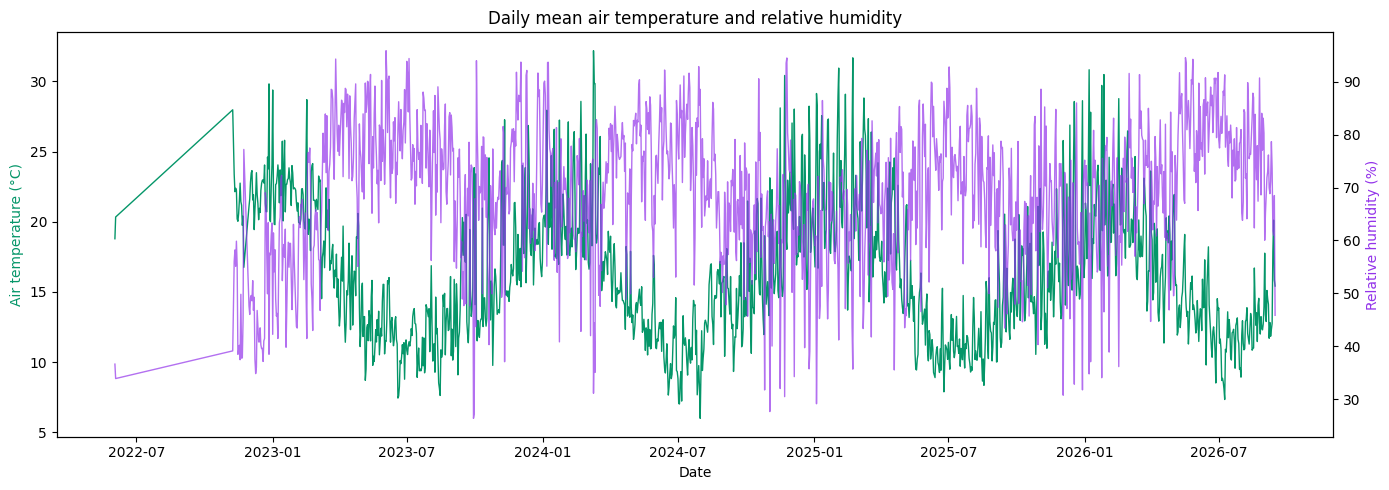

In [ ]:
# Daily means make the seasonal signal visible
daily_climate = (
    mc_clean.set_index("timestamp")[["airtemperature", "relativehumidity"]]
    .resample("D")
    .mean()
    .dropna()
)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(daily_climate.index, daily_climate["airtemperature"],
         color=MOP_COLOURS[0], linewidth=1)
ax1.set_xlabel("Date")
ax1.set_ylabel("Air temperature (°C)", color=MOP_COLOURS[0])

ax2 = ax1.twinx()
ax2.plot(daily_climate.index, daily_climate["relativehumidity"],
         color=MOP_COLOURS[1], linewidth=1, alpha=0.7)
ax2.set_ylabel("Relative humidity (%)", color=MOP_COLOURS[1])

plt.title("Daily mean air temperature and relative humidity")
plt.tight_layout()
plt.show()

<div class="usecase-body">
Two lines share this chart each with its own scale. Temperature is read against the left axis and humidity against the right. The horizontal axis runs across several years, so you are seeing a sequence of Melbourne summers and winters. The two lines should rise and fall in opposition.
</div>

<div class="usecase-body">
Temperature and humidity move in opposition across the year which is the expected relationship: warmer air holds more water before saturating, so relative humidity falls as temperature rises. The gap between the two is what drives evaporative demand.
</div>

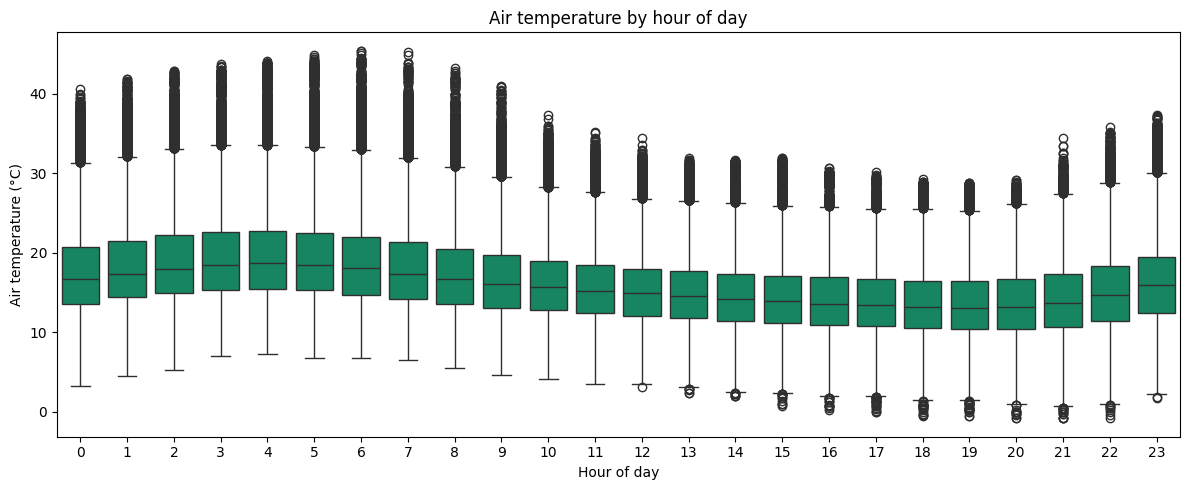

In [ ]:
# Temperature by hour of day pooled across sensors.
hourly = mc_clean.copy()
hourly["hour"] = hourly["timestamp"].dt.hour

plt.figure(figsize=(12, 5))
sns.boxplot(x="hour", y="airtemperature", data=hourly, color=MOP_COLOURS[0])
plt.title("Air temperature by hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Air temperature (°C)")
plt.tight_layout()
plt.show()

<div class="usecase-body">
Each box summarises every temperature reading taken during that hour, across all sensors and all dates. The line inside the box is the middle reading, with half the readings warmer and half cooler. The box covers the middle half of all readings and the thin lines reach most of the remainder. Individual dots beyond them are unusually hot or cold hours.
</div>

<div id="subsection-3-2" class="usecase-sub-section-heading"><b>3.2 Soil moisture patterns</b></div>

<div class="usecase-body">
Soil moisture cannot fall below zero or rise above the point where the soil is completely saturated, so every reading sits somewhere between those limits.

Different sites behave quite differently. Heavy clay holds water far longer than sandy soil and an irrigated garden bed behaves differently again from an unwatered patch of park. The chart below pools every site together, so its shape reflects that mixture as much as it reflects any one place.
</div>

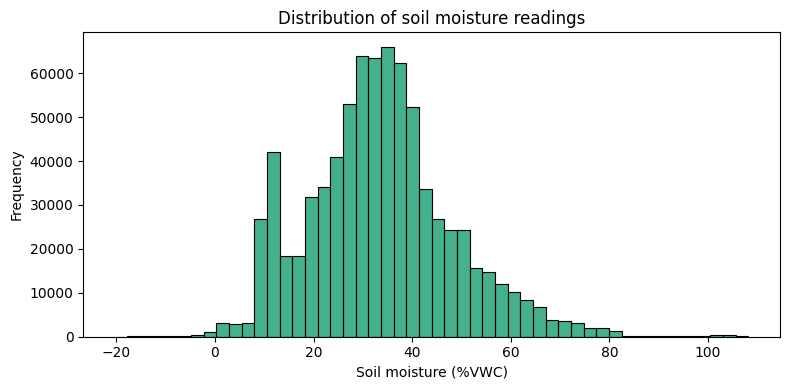

Across every site and every reading, soil moisture averages 33.6% volumetric water content.
Half of all readings fall between 24.2% and 41.3%.
The driest reading is -20.3% and the wettest 108.2%.

A reading near zero means completely dry soil, readings above roughly 40% mean
soil holding about as much water as it can.


In [37]:
plt.figure(figsize=(8, 4))
sns.histplot(soil_clean["soil_value"], bins=50, color=MOP_COLOURS[0])
plt.title("Distribution of soil moisture readings")
plt.xlabel("Soil moisture (%VWC)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

stats = soil_clean["soil_value"].describe()
print(f"Across every site and every reading, soil moisture averages "
      f"{stats['mean']:.1f}% volumetric water content.")
print(f"Half of all readings fall between {stats['25%']:.1f}% and {stats['75%']:.1f}%.")
print(f"The driest reading is {stats['min']:.1f}% and the wettest {stats['max']:.1f}%.")
print()
print("A reading near zero means completely dry soil, readings above roughly 40% mean")
print("soil holding about as much water as it can.")

<div class="usecase-body">
Each bar counts how many readings fell into that range of soil moisture, so taller bars are more common values. More than one peak would suggest the sites are not all alike, with different soils settling around different typical levels.
</div>

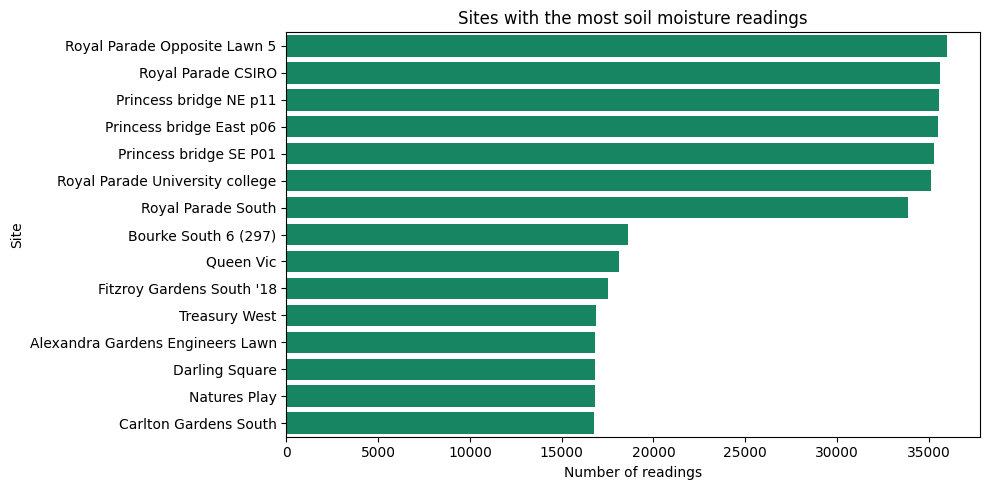

In [ ]:
# Which sites contribute the most observations.
# The readings already carry site_name so no merge is needed here.
site_counts = soil_clean["site_name"].value_counts().head(15)

plt.figure(figsize=(10, 5))
sns.barplot(y=site_counts.index, x=site_counts.values, color=MOP_COLOURS[0])
plt.title("Sites with the most soil moisture readings")
plt.xlabel("Number of readings")
plt.ylabel("Site")
plt.tight_layout()
plt.show()

<div class="usecase-body">
The length of each bar is simply how many readings that site has contributed. This says nothing about how wet those sites are, only how much data each one supplies, which matters because a city-wide average would otherwise be pulled towards whichever sites report most often.
</div>

<div class="usecase-body">
Observations are not spread evenly across sites. A handful of locations contribute a large share of the readings. Any city-wide average is weighted towards those sites unless the analysis aggregates per site first.
</div>

<div id="subsection-3-3" class="usecase-sub-section-heading"><b>3.3 Correlation structure</b></div>

<div class="usecase-body">
A correlation measures whether two things move together. The chart below checks every pair of microclimate measurements against each other which tells us whether some of them are effectively saying the same thing twice.

This matters later. If two measurements carry near-identical information a model can lean on either one, which makes it harder to say which actually mattered.
</div>

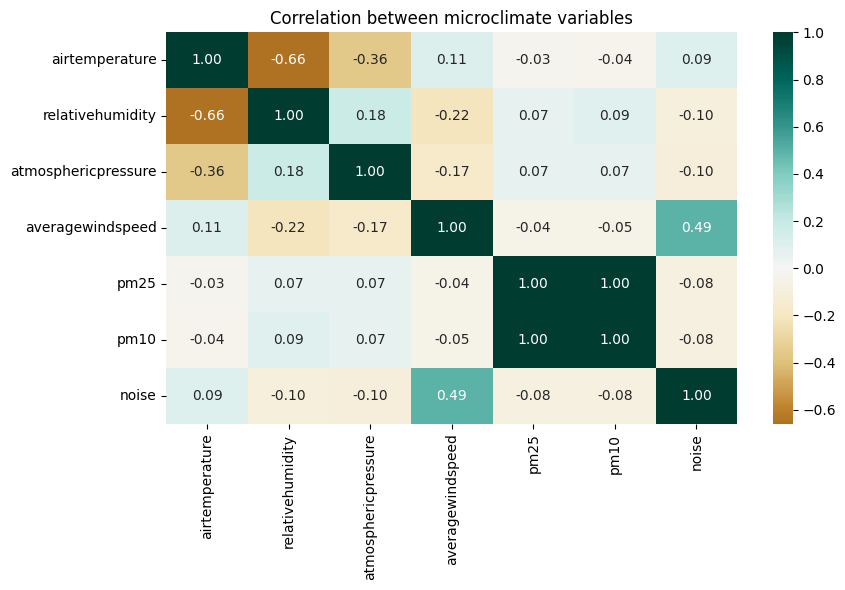

In [11]:
climate_vars = ["airtemperature", "relativehumidity", "atmosphericpressure",
                "averagewindspeed", "pm25", "pm10", "noise"]
available = [c for c in climate_vars if c in mc_clean.columns]

plt.figure(figsize=(9, 6))
sns.heatmap(mc_clean[available].corr(), annot=True, fmt=".2f", cmap="BrBG", center=0)
plt.title("Correlation between microclimate variables")
plt.tight_layout()
plt.show()

<div class="usecase-body">
Each square shows how closely two measurements move together, on a scale from -1 to 1. Near 1 means they rise and fall together. Near -1 means one rises as the other falls. Near 0 means they are unrelated. The diagonal is always 1 because every measurement matches itself. Temperature and humidity should show a strong negative value since warm air is usually less humid.
</div>

<div id="section-4" class="usecase-section-heading"><b>4. Linking microclimate readings to soil sites</b></div>

<div class="usecase-body">
The two networks share no common identifier. Soil sites are named after parks and garden beds, microclimate sensors after streets, poles and rooftops. The obvious move is to match the two name fields directly and it is worth seeing how badly that fails before trying another approach.

The soil readings do carry a <code>site_id</code> and the soil sensor locations dataset documents that key, so soil readings can be given coordinates exactly. The microclimate readings carry their own coordinates. With both sides geocoded each soil site can be matched to its nearest sensor.
</div>

<div id="subsection-4-1" class="usecase-sub-section-heading"><b>4.1 Choosing which sensors to use</b></div>

<div class="usecase-body">
 Several live sensors are mounted on rooftops which measure the air above a building rather than the conditions at ground level in a garden bed. Since the question here is about the microclimate a soil site actually experiences, rooftop sensors are excluded even where they happen to be the closest.
</div>

In [ ]:
# One row per sensor using the median of its reported coordinates.
sensors = (
    mc_clean.groupby("sensorlocation")[["latitude", "longitude"]]
    .median()
    .reset_index()
)

# Rooftop sensors measure air above a building but not conditions in a garden bed.
is_rooftop = sensors["sensorlocation"].str.contains("rooftop", case=False, na=False)

print("Sensors excluded as rooftop-mounted:")
for name in sensors.loc[is_rooftop, "sensorlocation"]:
    print(f"  - {name}")

ground_sensors = sensors.loc[~is_rooftop].reset_index(drop=True)

print(f"\nGround-level sensors retained: {len(ground_sensors)} of {len(sensors)}")
print(ground_sensors.to_string(index=False))

Sensors excluded as rooftop-mounted:
  - 101 Collins St L11 Rooftop
  - CH1 rooftop
  - SkyFarm (Jeff’s Shed). Rooftop - Melbourne Conference & Exhibition Centre (MCEC)

Ground-level sensors retained: 8 of 11
                                                         sensorlocation   latitude  longitude
                                                       1 Treasury Place -37.812860 144.974539
                                                            Batman Park -37.822183 144.956222
                                        Birrarung Marr Park - Pole 1131 -37.818593 144.971640
                                     Enterprize Park - Pole ID: COM1667 -37.820408 144.959119
                                           Royal Park Asset ID: COM2707 -37.795617 144.951901
Swanston St - Tram Stop 13 adjacent Federation Sq & Flinders St Station -37.818452 144.967847
      Tram Stop 7B – Melbourne Tennis Centre Precinct – Rod Laver Arena -37.819499 144.978721
      Tram Stop 7C – Melbourne Tennis C

<div id="subsection-4-2" class="usecase-sub-section-heading"><b>4.2 Nearest-sensor join</b></div>

<div class="usecase-body">
Distances between two points on the Earth are calculated with the haversine formula, which accounts for the planet's curvature. Over a few kilometres the curvature barely matters but the formula is short and avoids having to convert the coordinates into a flat map projection first.

A one-kilometre limit is then applied. Any soil site with no ground-level sensor within a kilometre is set aside rather than paired with a sensor that is too far away to describe its conditions.

The count printed below tells you how much of the soil network the microclimate sensors can actually cover. 
</div>

In [ ]:
MAX_DISTANCE_KM = 1.0


def haversine_km(lat1, lon1, lat2, lon2):
    #Great-circle distance in kilometres between one point and an array of points
    radius = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return 2 * radius * np.arcsin(np.sqrt(a))


# Match every soil site to its nearest ground-level sensor.
sites = soil_sites.dropna(subset=["latitude", "longitude"]).copy()
sites["latitude"] = pd.to_numeric(sites["latitude"], errors="coerce")
sites["longitude"] = pd.to_numeric(sites["longitude"], errors="coerce")
sites = sites.dropna(subset=["latitude", "longitude"])

matches = []
for _, site in sites.iterrows():
    distances = haversine_km(site["latitude"], site["longitude"],
                             ground_sensors["latitude"].values,
                             ground_sensors["longitude"].values)
    nearest = int(np.argmin(distances))
    matches.append({
        "site_id": site["site_id"],
        "site_name": site["site_name"],
        "property_name": site.get("property_name"),
        "sensorlocation": ground_sensors.iloc[nearest]["sensorlocation"],
        "distance_km": round(float(distances[nearest]), 3),
    })

site_sensor = pd.DataFrame(matches)
within_range = site_sensor[site_sensor["distance_km"] <= MAX_DISTANCE_KM].copy()

print(f"Soil sites total: {len(site_sensor)}")
print(f"Within {MAX_DISTANCE_KM} km of a ground-level sensor: {len(within_range)}")
print(f"Distinct sensors used: {within_range['sensorlocation'].nunique()}")
print(f"Distinct parks covered: {within_range['property_name'].nunique()}")
print(f"\nMedian pairing distance: {within_range['distance_km'].median():.3f} km")
print(f"Maximum pairing distance: {within_range['distance_km'].max():.3f} km")

Soil sites total: 84
Within 1.0 km of a ground-level sensor: 50
Distinct sensors used: 6
Distinct parks covered: 11

Median pairing distance: 0.577 km
Maximum pairing distance: 0.979 km


In [14]:
# How many sites would match if we simply compared the two name fields?
name_matches = set(soil_sites["site_name"].dropna()) & set(sensors["sensorlocation"].dropna())
print(f"Matching on name alone: {len(name_matches)} of {len(soil_sites)} sites")
for name in sorted(name_matches):
    print(f"  - {name}")
print()
print(f"Matching on location, within {MAX_DISTANCE_KM} km: {len(within_range)} sites")
print()
print("The two networks name their sites by different conventions, so almost nothing")
print("lines up by text. Position is the only thing they genuinely have in common.")

Matching on name alone: 1 of 84 sites
  - Batman Park

Matching on location, within 1.0 km: 50 sites

The two networks name their sites by different conventions, so almost nothing
lines up by text. Position is the only thing they genuinely have in common.


<div class="usecase-body">
Of the 84 soil sites 50 sit within a kilometre of a ground-level microclimate sensor, drawing on 6 sensors across 11 parks and gardens. Matching on name would have left a single site so an analysis built that way would describe one park while appearing to describe the city.

The 34 sites that fall outside the threshold are not bad data. They are sites the sensor network does not currently cover, mostly in the northern half of Royal Park and around the Shrine.
</div>

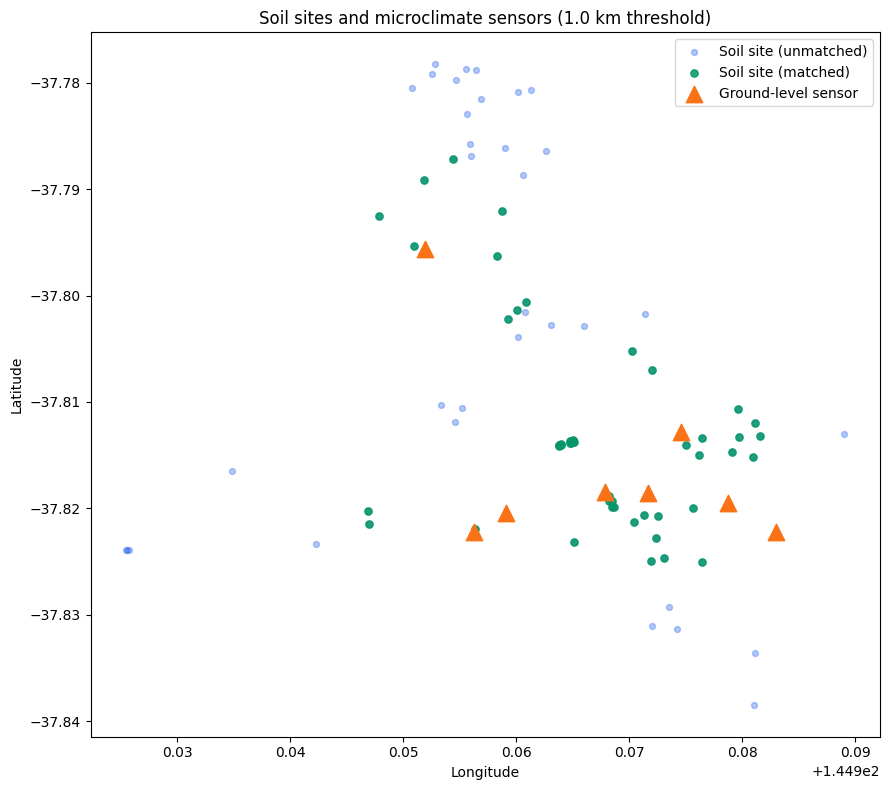

In [15]:
# Map of the retained pairings.
plt.figure(figsize=(9, 8))
plt.scatter(sites["longitude"], sites["latitude"],
            s=18, alpha=0.35, color=MOP_COLOURS[3], label="Soil site (unmatched)")
matched_sites = sites[sites["site_id"].isin(within_range["site_id"])]
plt.scatter(matched_sites["longitude"], matched_sites["latitude"],
            s=28, alpha=0.85, color=MOP_COLOURS[0], label="Soil site (matched)")
plt.scatter(ground_sensors["longitude"], ground_sensors["latitude"],
            s=140, marker="^", color=MOP_COLOURS[2], label="Ground-level sensor")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Soil sites and microclimate sensors ({MAX_DISTANCE_KM} km threshold)")
plt.legend()
plt.tight_layout()
plt.show()

<div class="usecase-body">
This is a rough map with longitude across the bottom and latitude up the side. Orange triangles are microclimate sensors. Green dots are soil sites close enough to be paired with one. Pale blue dots are soil sites with no sensor near enough to use. Groups of green around a triangle are the parks this analysis can actually speak about.
</div>

In [16]:
# Restrict the soil readings to the matched sites before any heavy processing.
# site_name is already present in the readings. Taking it from the locations
# side as well would produce site_name_x and site_name_y.
soil_matched = soil_clean.merge(
    within_range[["site_id", "property_name", "sensorlocation", "distance_km"]],
    on="site_id",
    how="inner",
)

kept = 100 * len(soil_matched) / len(soil_clean)
print(f"Keeping only the sites close enough to a sensor leaves {len(soil_matched):,} "
      f"soil readings, {kept:.1f}% of what we started with,")
print(f"spread across {soil_matched['site_id'].nunique()} sites.")
print()
print("The readings we set aside are not faulty. They come from sites the sensor")
print("network does not currently reach.")

Keeping only the sites close enough to a sensor leaves 512,890 soil readings, 65.9% of what we started with,
spread across 41 sites.

The readings we set aside are not faulty. They come from sites the sensor
network does not currently reach.


<div id="section-5" class="usecase-section-heading"><b>5. Feature engineering</b></div>

<div class="usecase-body">
Both networks report more often than daily. Aggregating to daily values per site and per sensor gives a common resolution to join on. Soil moisture responds to accumulated conditions rather than to individual fifteen-minute readings.
</div>

<div id="subsection-5-1" class="usecase-sub-section-heading"><b>5.1 Microclimate features</b></div>

<div class="usecase-body">
Warm air holds more water than cold air before it becomes saturated. Vapour-pressure deficit uses that fact to combine temperature and humidity into one number describing how strongly the air is pulling moisture out of the ground and out of plants.

It works better than temperature or humidity on their own because the same humidity reading means very different things on a 15°C day and a 35°C day.

The code also calculates seven-day averages, known as rolling averages because the seven-day window moves along with each new day. A single hot day matters less to the soil than a hot week and a rolling average captures that build-up.
</div>

In [ ]:
def vapour_pressure_deficit(temp_c, relative_humidity):
    
    #Vapour-pressure deficit in kPa.

    #Saturation vapour pressure follows the Tetens approximation. The difference is how
    #much more water the air could hold which is what drives evaporation.
    
    saturation = 0.6108 * np.exp((17.27 * temp_c) / (temp_c + 237.3))
    actual = saturation * (relative_humidity / 100.0)
    return saturation - actual


mc_features = mc_clean.copy()
mc_features["vpd_kpa"] = vapour_pressure_deficit(
    mc_features["airtemperature"], mc_features["relativehumidity"]
)
mc_features["date"] = mc_features["timestamp"].dt.date

# Daily summary per sensor.
climate_daily = (
    mc_features.groupby(["sensorlocation", "date"])
    .agg(
        air_temp=("airtemperature", "mean"),
        air_temp_max=("airtemperature", "max"),
        humidity=("relativehumidity", "mean"),
        wind_speed=("averagewindspeed", "mean"),
        vpd=("vpd_kpa", "mean"),
    )
    .reset_index()
    .sort_values(["sensorlocation", "date"])
)

# Accumulated conditions which are more meaningful 
for column in ["air_temp", "vpd"]:
    climate_daily[f"{column}_7d"] = (
        climate_daily.groupby("sensorlocation")[column]
        .transform(lambda s: s.rolling(7, min_periods=3).mean())
    )

print(f"Condensed the sensor readings into {len(climate_daily):,} daily summaries,")
print("one per sensor per day. A sample of the first few:")
print()
print(climate_daily.head().to_string(index=False))

Condensed the sensor readings into 10,532 daily summaries,
one per sensor per day. A sample of the first few:

  sensorlocation       date  air_temp  air_temp_max  humidity  wind_speed      vpd  air_temp_7d   vpd_7d
1 Treasury Place 2024-08-13 15.521053          19.8 75.090526    2.149474 0.475418          NaN      NaN
1 Treasury Place 2024-08-14 16.120833          20.7 76.071875    2.229167 0.477847          NaN      NaN
1 Treasury Place 2024-08-15 16.301042          20.3 71.630208    1.989583 0.554154    15.980976 0.502473
1 Treasury Place 2024-08-16 12.422917          15.6 86.390625    1.931250 0.217235    15.091461 0.431163
1 Treasury Place 2024-08-17 11.928125          14.7 93.145833    1.045833 0.101730    14.458794 0.365277


<div id="subsection-5-2" class="usecase-sub-section-heading"><b>5.2 Soil moisture features</b></div>

<div class="usecase-body">
The soil readings are averaged down to one value per site per day.

Two extra columns are then added. The first is how much the moisture moved since the day before, calculated separately for each site so a change is never accidentally measured between two different locations. The second is the site's seven-day average, which describes where its moisture has been sitting recently rather than on any single day.
</div>

In [38]:
soil_matched["date"] = soil_matched["timestamp"].dt.date

# Not every site records the park it sits in. pandas drops rows whose group key
# is missing
soil_matched["property_name"] = soil_matched["property_name"].fillna("(not recorded)")

soil_daily = (
    soil_matched.groupby(["site_id", "site_name", "property_name",
                          "sensorlocation", "date"])
    .agg(soil_moisture=("soil_value", "mean"))
    .reset_index()
    .sort_values(["site_id", "date"])
)

# Confirm no sites were lost between the join and the daily aggregation
print(f"Sites entering aggregation: {soil_matched['site_id'].nunique()}")
print(f"Sites after aggregation:    {soil_daily['site_id'].nunique()}")

# Differences are computed within a site so they never span two locations
soil_daily["soil_moisture_change"] = soil_daily.groupby("site_id")["soil_moisture"].diff()
soil_daily["soil_moisture_7d"] = (
    soil_daily.groupby("site_id")["soil_moisture"]
    .transform(lambda s: s.rolling(7, min_periods=3).mean())
)

print(f"Condensed the soil readings into {len(soil_daily):,} daily summaries,")
print(f"covering {soil_daily['site_id'].nunique()} sites across "
      f"{soil_daily['date'].nunique()} days.")
print()
print("Each row is one site on one day, with its average moisture, how much that")
print("moved since yesterday and its average over the past week:")
print()
print(soil_daily.head().to_string(index=False))

Sites entering aggregation: 41
Sites after aggregation:    41
Condensed the soil readings into 17,209 daily summaries,
covering 41 sites across 684 days.

Each row is one site on one day, with its average moisture, how much that
moved since yesterday and its average over the past week:

 site_id              site_name    property_name   sensorlocation       date  soil_moisture  soil_moisture_change  soil_moisture_7d
   64977 Treasury Gardens South Treasury Gardens 1 Treasury Place 2023-12-31      29.305714                   NaN               NaN
   64977 Treasury Gardens South Treasury Gardens 1 Treasury Place 2024-01-01      31.911429              2.605714               NaN
   64977 Treasury Gardens South Treasury Gardens 1 Treasury Place 2024-01-02      32.585882              0.674454         31.267675
   64977 Treasury Gardens South Treasury Gardens 1 Treasury Place 2024-01-03      30.399286             -2.186597         31.050578
   64977 Treasury Gardens South Treasury Gardens 1 T

In [39]:
# Join each site-day to its paired sensor's conditions for that day
combined = soil_daily.merge(
    climate_daily,
    on=["sensorlocation", "date"],
    how="inner",
)

print(f"Every soil site now has the weather its nearest sensor recorded that day.")
print(f"That gives {len(combined):,} site-days across "
      f"{combined['site_id'].nunique()} sites,")
print(f"from {combined['date'].min()} to {combined['date'].max()}.")
print()


Every soil site now has the weather its nearest sensor recorded that day.
That gives 13,121 site-days across 38 sites,
from 2023-12-31 to 2026-09-13.



<div id="section-6" class="usecase-section-heading"><b>6. Temporal trends</b></div>

<div class="usecase-body">
With sites and conditions aligned, the seasonal relationship between evaporative demand and soil moisture can be examined directly.
</div>

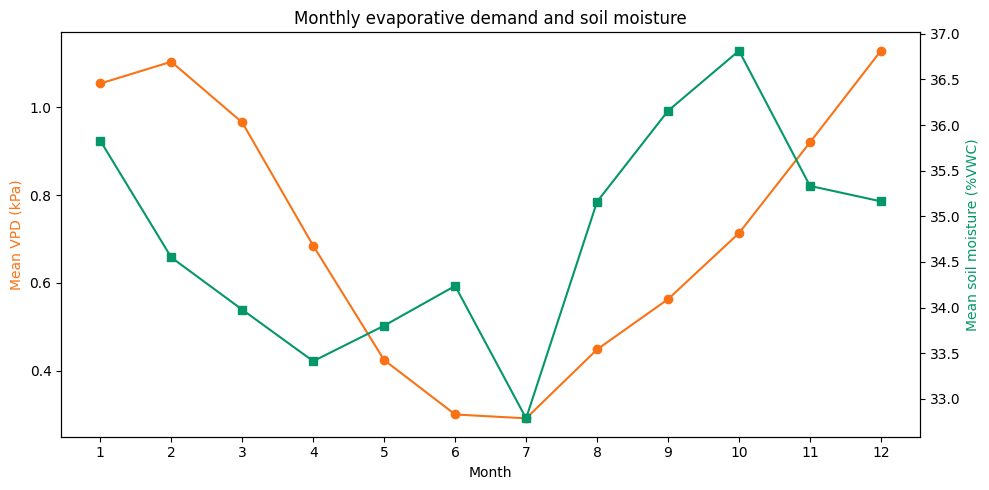

In [20]:
monthly = combined.copy()
monthly["month"] = pd.to_datetime(monthly["date"]).dt.month

monthly_means = monthly.groupby("month").agg(
    vpd=("vpd", "mean"),
    soil_moisture=("soil_moisture", "mean"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(monthly_means["month"], monthly_means["vpd"],
         marker="o", color=MOP_COLOURS[2], label="VPD")
ax1.set_xlabel("Month")
ax1.set_ylabel("Mean VPD (kPa)", color=MOP_COLOURS[2])
ax1.set_xticks(range(1, 13))

ax2 = ax1.twinx()
ax2.plot(monthly_means["month"], monthly_means["soil_moisture"],
         marker="s", color=MOP_COLOURS[0], label="Soil moisture")
ax2.set_ylabel("Mean soil moisture (%VWC)", color=MOP_COLOURS[0])

plt.title("Monthly evaporative demand and soil moisture")
plt.tight_layout()
plt.show()

<div class="usecase-body">
Months run left to right from January to December combining all years. The orange line is how hard the air was pulling moisture out of the ground, read against the left axis. The green line is average soil moisture, read against the right. The two moving in opposite directions is the seasonal pattern you would expect, with drier soil through the hot months.
</div>

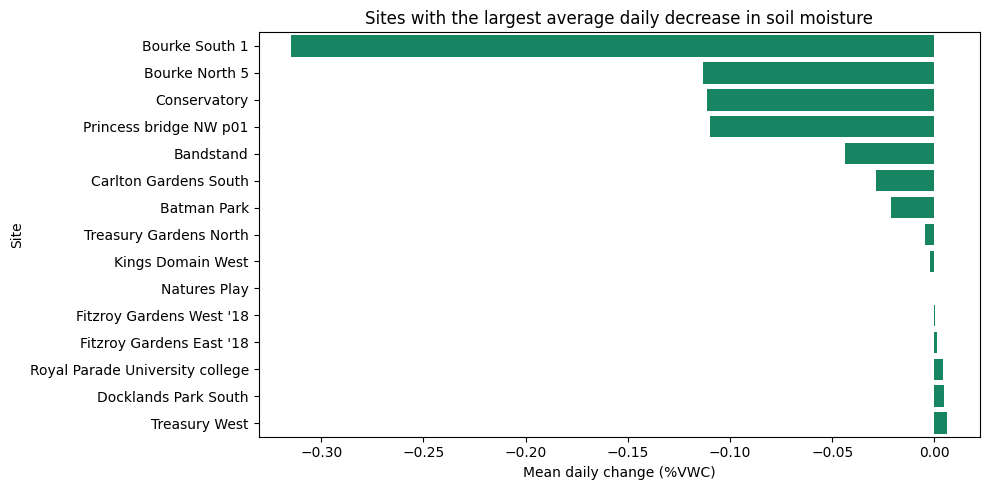

In [21]:
# Which sites dry fastest on average.
drying = (
    combined.groupby("site_name")["soil_moisture_change"]
    .mean()
    .sort_values()
    .head(15)
)

plt.figure(figsize=(10, 5))
sns.barplot(y=drying.index, x=drying.values, color=MOP_COLOURS[0])
plt.title("Sites with the largest average daily decrease in soil moisture")
plt.xlabel("Mean daily change (%VWC)")
plt.ylabel("Site")
plt.tight_layout()
plt.show()

<div class="usecase-body">
Each bar is one site's average day-to-day change in soil moisture. The bars run to the left because these values are negative: these are the sites losing moisture fastest from one day to the next. A longer bar means a faster average loss.
</div>

<div id="section-7" class="usecase-section-heading"><b>7. Clustering analysis</b></div>

<div class="usecase-body">
Clustering sorts the data into groups without being told what to look for. Here each item being sorted is one site on one day, described by its soil moisture and the weather conditions that day. 

Two preparation steps are needed. First the measurements are put on a common scale because the method works by measuring distances between data points and without rescaling. Humidity running from 0 to 100 would completely overwhelm soil moisture change running from about -2 to 2.

Second, the number of groups has to be chosen. Rather than picking a number the code tries several and scores each with a silhouette score, which measures how neatly separated the groups are. Higher is better and the best-scoring option is used.
</div>

In [22]:
cluster_features = ["vpd", "air_temp", "humidity", "soil_moisture", "soil_moisture_change"]
cluster_data = combined.dropna(subset=cluster_features).copy()

X_scaled = StandardScaler().fit_transform(cluster_data[cluster_features])

# Silhouette score across candidate cluster counts.
scores = {}
for k in range(2, 8):
    labels = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10).fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels, sample_size=10000,
                                 random_state=RANDOM_SEED)

for k, score in scores.items():
    print(f"  k={k}: silhouette {score:.3f}")

best_k = max(scores, key=scores.get)
print(f"\nSelected k = {best_k}")

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_SEED, n_init=10)
cluster_data["cluster"] = kmeans.fit_predict(X_scaled)

  k=2: silhouette 0.304
  k=3: silhouette 0.254
  k=4: silhouette 0.269
  k=5: silhouette 0.282
  k=6: silhouette 0.290
  k=7: silhouette 0.244

Selected k = 2


In [ ]:
# Cluster profiles. the mean of each feature within each cluster.
profile = cluster_data.groupby("cluster")[cluster_features].mean().round(2)
profile["n_site_days"] = cluster_data["cluster"].value_counts().sort_index()


def describe_cluster(row):
    # plain-language label, derived from the cluster's own averages
    warmth = "warm" if row["air_temp"] >= profile["air_temp"].median() else "cool"
    air = "dry air" if row["humidity"] < profile["humidity"].median() else "humid air"
    trend = "soil drying" if row["soil_moisture_change"] < 0 else "soil wetting"
    return f"{warmth}, {air}, {trend}"


profile["description"] = profile.apply(describe_cluster, axis=1)
print(profile.to_string())
print()
for cluster_id, row in profile.iterrows():
    share = 100 * row["n_site_days"] / profile["n_site_days"].sum()
    print(f"Cluster {cluster_id}: {row['description']}. "
          f"{int(row['n_site_days']):,} site-days ({share:.0f}% of the total), "
          f"averaging {row['air_temp']:.1f}°C and "
          f"{row['soil_moisture']:.1f}% soil moisture.")

          vpd  air_temp  humidity  soil_moisture  soil_moisture_change  n_site_days                    description
cluster                                                                                                           
0        1.19     20.66     57.79          33.81                 -0.08         4206     warm, dry air, soil drying
1        0.38     13.15     77.07          34.93                  0.05         8901  cool, humid air, soil wetting

Cluster 0: warm, dry air, soil drying. 4,206 site-days (32% of the total), averaging 20.7°C and 33.8% soil moisture.
Cluster 1: cool, humid air, soil wetting. 8,901 site-days (68% of the total), averaging 13.2°C and 34.9% soil moisture.


<div class="usecase-body">
Two groups separate the data most cleanly and what separates them is essentially the season. One group is cool and humid, with soil moisture drifting slightly upwards. The other is warm and dry, with soil moisture drifting slightly down.

What the groups do not do is separate the sites. The average soil moisture in the two groups differs by around one percentage point which is very little compared with the gap in temperature or humidity between them. So the clustering has rediscovered Melbourne's seasons rather than identifying sites that behave differently from one another.

Telling sites apart would need information about the sites themselves — what the soil is made of, how much shade they get, whether they are watered — and none of that is in these datasets.
</div>

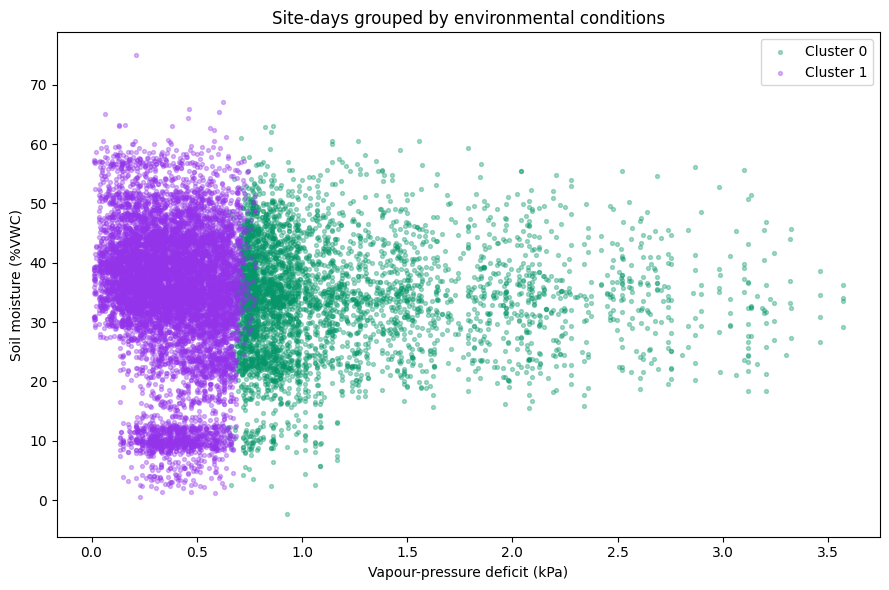

In [24]:
plt.figure(figsize=(9, 6))
for cluster_id in sorted(cluster_data["cluster"].unique()):
    subset = cluster_data[cluster_data["cluster"] == cluster_id]
    plt.scatter(subset["vpd"], subset["soil_moisture"],
                s=8, alpha=0.35,
                color=MOP_COLOURS[cluster_id % len(MOP_COLOURS)],
                label=f"Cluster {cluster_id}")
plt.xlabel("Vapour-pressure deficit (kPa)")
plt.ylabel("Soil moisture (%VWC)")
plt.title("Site-days grouped by environmental conditions")
plt.legend()
plt.tight_layout()
plt.show()

<div class="usecase-body">
Every dot is one site on one day. Its position left to right is how hard the air was pulling moisture that day and its height is how wet the soil was. The colours are the groups the clustering found.
</div>

<div id="section-8" class="usecase-section-heading"><b>8. Predicting next-day soil moisture</b></div>

<div class="usecase-body">
The question is whether today's conditions tell us anything about tomorrow's soil moisture at the same site.

Two decisions that are important here. The first is how the data is divided for testing. A model is trained on one portion of the data and tested on another it has never seen. Splitting that at random would be a mistake because soil moisture on consecutive days is nearly identical. A Tuesday in the training set and the following Wednesday in the test set would let the model score well by recognising something it had already been shown. So the split is made by date, training on the earlier period and testing on the later one.

The second is that the model needs something to be compared against. Soil moisture changes slowly so "tomorrow will be much like today" is already a good guess.
</div>

In [ ]:
model_data = combined.sort_values(["site_id", "date"]).copy()

# Tomorrow's soil moisture at the same site.
model_data["target"] = model_data.groupby("site_id")["soil_moisture"].shift(-1)

FEATURES = [
    "soil_moisture", "soil_moisture_change", "soil_moisture_7d",
    "vpd", "vpd_7d", "air_temp", "air_temp_max", "air_temp_7d",
    "humidity", "wind_speed",
]

model_data = model_data.dropna(subset=FEATURES + ["target"])
model_data["date"] = pd.to_datetime(model_data["date"])

# Chronological split. the last 20% of the calendar is held out.
split_date = model_data["date"].quantile(0.8)
train = model_data[model_data["date"] <= split_date]
test = model_data[model_data["date"] > split_date]

print(f"Train: {len(train):,} site-days, up to {split_date.date()}")
print(f"Test:  {len(test):,} site-days, after {split_date.date()}")

Train: 10,428 site-days, up to 2025-06-29
Test:  2,604 site-days, after 2025-06-29


<div id="subsection-8-1" class="usecase-sub-section-heading"><b>8.1 Persistence baseline</b></div>

<div class="usecase-body">
The persistence baseline is the simplest possible prediction, tomorrow's soil moisture will be whatever today's was. It involves no model and no learning.

It is included because a number on its own means very little. Knowing a model is right to within half a percentage point only becomes useful when you know what guessing would have achieved.
</div>

In [34]:
baseline_pred = test["soil_moisture"]
baseline_rmse = mean_squared_error(test["target"], baseline_pred) ** 0.5
baseline_mae = mean_absolute_error(test["target"], baseline_pred)
baseline_r2 = r2_score(test["target"], baseline_pred)

print("Persistence baseline (assume tomorrow is the same as today)")
print(f"  RMSE: {baseline_rmse:.3f}")
print(f"  MAE:  {baseline_mae:.3f}")
print(f"  R2:   {baseline_r2:.3f}")
print()
print(f"Guessing that nothing changes overnight is typically wrong")
print(f"by about {baseline_mae:.2f} percentage points of soil moisture.")
print("R2 is the share of the variation explained, where 1.0 is perfect. It looks")
print("high here because soil moisture barely moves overnight")

Persistence baseline (assume tomorrow is the same as today)
  RMSE: 1.466
  MAE:  0.606
  R2:   0.985

Guessing that nothing changes overnight is typically wrong
by about 0.61 percentage points of soil moisture.
R2 is the share of the variation explained, where 1.0 is perfect. It looks
high here because soil moisture barely moves overnight


<div id="subsection-8-2" class="usecase-sub-section-heading"><b>8.2 Random Forest model</b></div>

<div class="usecase-body">
A Random Forest builds a large number of simple decision trees, each looking at the data slightly differently and averages their answers. It handles mixed kinds of input well and does not assume relationships are straight lines.

It is given only what a person would know on the day: how wet the site is now, how wet it has been recently and what its nearest sensor recorded. Its results are reported next to the baseline above.
</div>

In [35]:
model = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=5,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
model.fit(train[FEATURES], train["target"])

predictions = model.predict(test[FEATURES])
model_rmse = mean_squared_error(test["target"], predictions) ** 0.5
model_mae = mean_absolute_error(test["target"], predictions)
model_r2 = r2_score(test["target"], predictions)

print("Random Forest")
print(f"  RMSE: {model_rmse:.3f}")
print(f"  MAE:  {model_mae:.3f}")
print(f"  R2:   {model_r2:.3f}")
print()
print(f"The model is typically wrong by about {model_mae:.2f} "
      "percentage points")
print("of soil moisture, against the baseline's "
      f"{baseline_mae:.2f}.")
print()
print("Change against the persistence baseline (positive means the model is better):")
print(f"  RMSE: {100 * (baseline_rmse - model_rmse) / baseline_rmse:+.1f}%")
print(f"  MAE:  {100 * (baseline_mae - model_mae) / baseline_mae:+.1f}%")

if model_rmse < baseline_rmse:
    print("\nThe model improves on simply carrying yesterday's reading forward.")
else:
    print("\nThe model does not beat carrying yesterday's reading forward.")

Random Forest
  RMSE: 1.741
  MAE:  1.012
  R2:   0.979

The model is typically wrong by about 1.01 percentage points
of soil moisture, against the baseline's 0.61.

Change against the persistence baseline (positive means the model is better):
  RMSE: -18.8%
  MAE:  -67.0%

The model does not beat carrying yesterday's reading forward.


<div class="usecase-body">
The model does not beat the simple baseline.

Both score very highly on R², a measure of how much of the variation has been explained where 1.0 would be perfect. But it is high here only because soil moisture barely moves overnight. Reported on its own it would look like a strong result.

The chart below shows which inputs the model relied on. Nearly all the weight sits on the site's own recent moisture and the weather measurements together account for very little. The model is producing a smoothed version of yesterday's reading and smoothing loses accuracy when the thing being predicted jumps around unpredictably from day to day.
</div>

<div id="subsection-8-3" class="usecase-sub-section-heading"><b>8.3 Feature importance</b></div>

<div class="usecase-body">
Feature importances show which inputs the model relied on. They should be read with the correlation structure from section 3.3: where two inputs carry similar information the model may lean on one and appear to ignore the other.
</div>

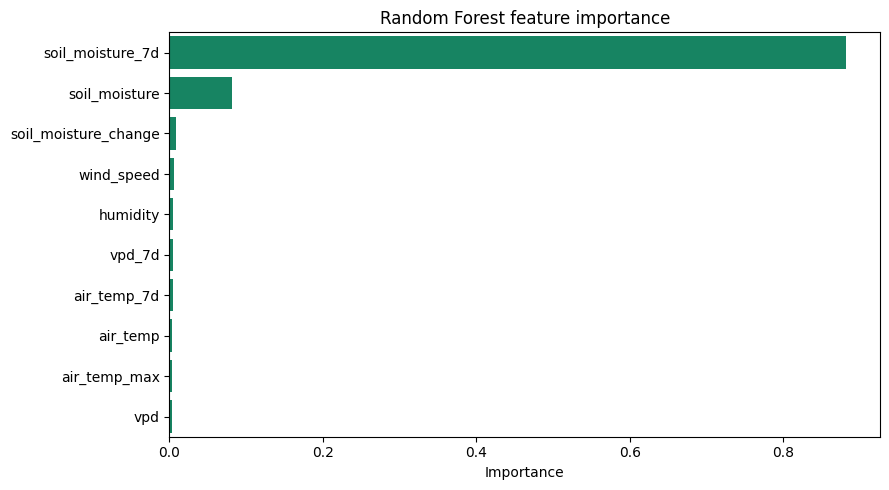

soil_moisture_7d        0.8823
soil_moisture           0.0816
soil_moisture_change    0.0079
wind_speed              0.0055
humidity                0.0043
vpd_7d                  0.0043
air_temp_7d             0.0040
air_temp                0.0035
air_temp_max            0.0033
vpd                     0.0033


In [28]:
importances = (
    pd.Series(model.feature_importances_, index=FEATURES)
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
sns.barplot(x=importances.values, y=importances.index, color=MOP_COLOURS[0])
plt.title("Random Forest feature importance")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

print(importances.round(4).to_string())

<div class="usecase-body">
Each bar shows how much the model relied on that piece of information. The bars total 1 between them, so a single bar taking up most of the width means the model was leaning on that one input for nearly everything and likely ignoring the rest.
</div>

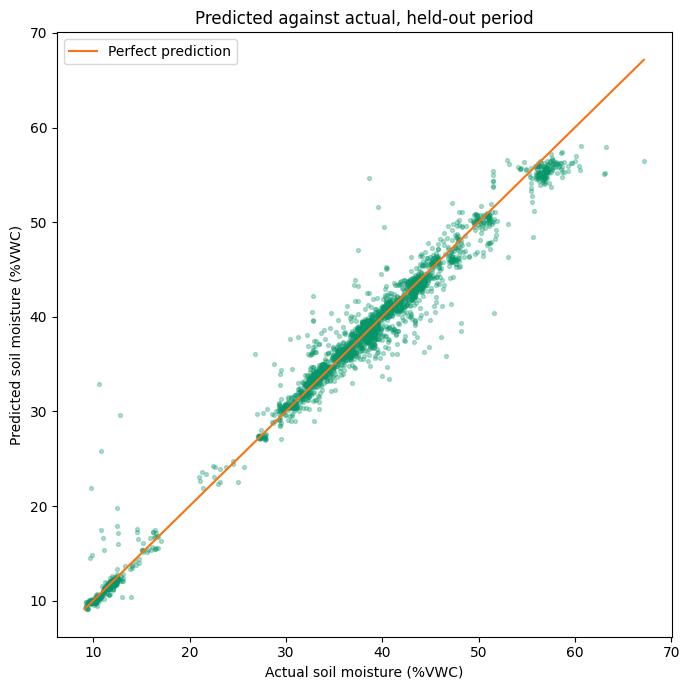

In [29]:
# Predicted against actual on the held-out period.
plt.figure(figsize=(7, 7))
plt.scatter(test["target"], predictions, s=8, alpha=0.3, color=MOP_COLOURS[0])
limits = [test["target"].min(), test["target"].max()]
plt.plot(limits, limits, color=MOP_COLOURS[2], linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual soil moisture (%VWC)")
plt.ylabel("Predicted soil moisture (%VWC)")
plt.title("Predicted against actual, held-out period")
plt.legend()
plt.tight_layout()
plt.show()

<div class="usecase-body">
Each dot is one prediction for one site on one day. Its horizontal position is what actually happened; its height is what the model predicted. The orange line marks where a perfect prediction would fall. Dots above the line are overestimates and dots below are underestimates, so a tight band hugging the line means close agreement.
</div>

<div id="subsection-8-4" class="usecase-sub-section-heading"><b>8.4 Predicting the day-to-day change</b></div>

<div class="usecase-body">
Section 8.2 asked the model to predict tomorrow's soil moisture level and the simple baseline won. That was never very informative because soil moisture changes so little overnight, most of the answer was already sitting in today's reading.

A better question is whether the weather predicts the <i>change</i> — not how wet the soil will be tomorrow, but how much it will move. The target becomes the difference between tomorrow and today and the thing to beat becomes the assumption that nothing moves at all.

</div>

In [ ]:
# Same features and the same chronological split only the target changes
change_train = train.copy()
change_test = test.copy()
change_train["target_change"] = change_train["target"] - change_train["soil_moisture"]
change_test["target_change"] = change_test["target"] - change_test["soil_moisture"]

# The no-change baseline predicts zero movement.
no_change = np.zeros(len(change_test))
base_change_rmse = mean_squared_error(change_test["target_change"], no_change) ** 0.5
base_change_mae = mean_absolute_error(change_test["target_change"], no_change)
base_change_r2 = r2_score(change_test["target_change"], no_change)

print("No-change baseline (assume the soil does not move at all)")
print(f"  RMSE: {base_change_rmse:.3f}")
print(f"  MAE:  {base_change_mae:.3f}")
print(f"  R2:   {base_change_r2:.3f}")
print()
print(f"On an average day the soil actually moves about {base_change_mae:.2f} "
      "percentage points,")
print("so that is the error you accept by assuming it stays still.")
print("An R2 of zero is expected here: predicting no change explains none of the")
print("variation, which is exactly what we want to test the model against.")

No-change baseline (assume the soil does not move at all)
  RMSE: 1.466
  MAE:  0.606
  R2:   -0.000

On an average day the soil actually moves about 0.61 percentage points,
so that is the error you accept by assuming it stays still.
An R2 of zero is expected here: predicting no change explains none of the
variation, which is exactly what we want to test the model against.


In [36]:
change_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=5,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
change_model.fit(change_train[FEATURES], change_train["target_change"])

change_pred = change_model.predict(change_test[FEATURES])
change_rmse = mean_squared_error(change_test["target_change"], change_pred) ** 0.5
change_mae = mean_absolute_error(change_test["target_change"], change_pred)
change_r2 = r2_score(change_test["target_change"], change_pred)

print("Random Forest predicting the change")
print(f"  RMSE: {change_rmse:.3f}")
print(f"  MAE:  {change_mae:.3f}")
print(f"  R2:   {change_r2:.3f}")
print()
print(f"The model's guess at tomorrow's movement is typically out")
print(f"by {change_mae:.2f} percentage points, against "
      f"{base_change_mae:.2f} for assuming no movement at all.")
if change_r2 < 0:
    print("A negative R2 means the model does worse than simply predicting the")
    print("average change for every day, which is a clear signal that the weather")
    print("data alone cannot explain how soil moisture moves.")
print()
print("Change against the no-change baseline (positive means the model is better):")
print(f"  RMSE: {100 * (base_change_rmse - change_rmse) / base_change_rmse:+.1f}%")
print(f"  MAE:  {100 * (base_change_mae - change_mae) / base_change_mae:+.1f}%")

Random Forest predicting the change
  RMSE: 1.614
  MAE:  0.868
  R2:   -0.213

The model's guess at tomorrow's movement is typically out
by 0.87 percentage points, against 0.61 for assuming no movement at all.
A negative R2 means the model does worse than simply predicting the
average change for every day, which is a clear signal that the weather
data alone cannot explain how soil moisture moves.

Change against the no-change baseline (positive means the model is better):
  RMSE: -10.1%
  MAE:  -43.3%


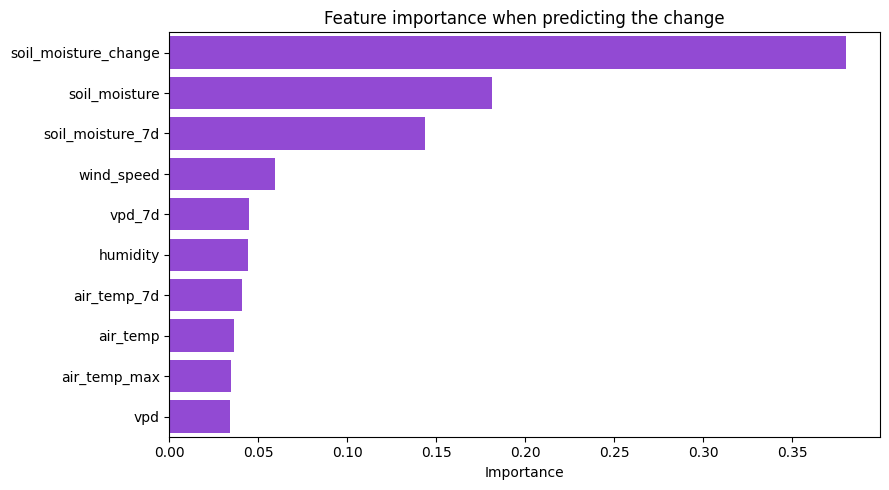

soil_moisture_change    0.3805
soil_moisture           0.1816
soil_moisture_7d        0.1437
wind_speed              0.0594
vpd_7d                  0.0449
humidity                0.0442
air_temp_7d             0.0405
air_temp                0.0365
air_temp_max            0.0347
vpd                     0.0341


In [ ]:
# Which features carry information about the change
change_importances = (
    pd.Series(change_model.feature_importances_, index=FEATURES)
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
sns.barplot(x=change_importances.values, y=change_importances.index,
            color=MOP_COLOURS[1])
plt.title("Feature importance when predicting the change")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

print(change_importances.round(4).to_string())

<div class="usecase-body">
The comparison between the two is the point: which inputs matter more when the model is asked to predict movement rather than level.
</div>

<div class="usecase-body">
When predicting the level the model leaned almost entirely on the site's own recent moisture and barely used the weather at all. When predicting the movement, wind speed, evaporative demand and humidity all take on real weight.

The model still does not beat assuming no change and its R² is negative. A negative R² means it does worse than simply guessing the average movement every single day. So the weather is not irrelevant here it is outweighed by something the data does not contain.

Rain and irrigation are the two biggest things that change soil moisture and neither is recorded in these datasets. A day when the sprinklers ran and a day when they did not look identical to this model.

This result is better read as pointing at the missing measurement.
</div>

<div class="usecase-unnumbered-heading"><b>Conclusion</b></div>

<div class="usecase-body">
The City of Melbourne runs two sets of sensors that werent designed to work together: one measuring the weather on the streets, the other measuring how much water is in the soil in parks and garden beds. This use case connected them and used the result to look at how the weather relates to the moisture in the ground.
</div>

**What we achieved in this analysis**

We connected two sets of sensors that had no shared reference between them. The soil
readings came with a site number and a separate council dataset lists where each of
those sites is which gave every soil reading a position on the map. The weather
sensors already report their own position. With both on the map, each soil site could
be paired with the weather sensor nearest to it.

From there we worked out how hard the air was pulling moisture out of the ground each
day, sorted the days into groups based on their conditions and tested whether the
weather could predict what the soil would do the following day.

**What we learned from this analysis**

How you connect two datasets is important.

The obvious way to link these two networks is by name. That produces exactly one
match out of 84 sites because the soil sites are named after parks and the weather
sensors are named after streets and buildings. An analysis built that way would be
describing a single park while looking like it was describing Melbourne. Matching on
location instead and only where a sensor is close enough to be meaningful, covers 50
sites across 11 parks — and shows which parts of the city have no nearby
sensor at all.

The second lesson is in interpreting results.

Soil moisture changes very slowly. Guess that tomorrow will be the same as today and
you will usually be close. So a model given yesterday's reading will always look
impressive, until you put that guess beside it and found the
model was actually doing slightly worse. Asking the question, how much the soil
will move rather than how wet it will be, gave the weather measurements a more input.
They mattered more there, but still not enough to beat assuming nothing
changes.

The grouping exercise was a similar story. Two clear types of day emerged, but they
turned out to be warm dry days and cool humid ones. That is the seasons showing up in
the data not a difference between one park and another.

**Observations for further opportunities**

Rainfall is the obvious missing piece. It is the single biggest thing that changes
soil moisture, and neither of these datasets records it, which is very likely why so
much of the day-to-day movement went unexplained. Watering schedules, if the council has them, would explain much of what is
left. A day the sprinklers ran and a day they did not look exactly
the same in this data.

Sensor coverage is another limitation. There are far fewer ground-level weather
sensors than there are soil sites and 34 of the 84 sites have no sensor within a
kilometre. More sensors in the parks, particularly in the northern half of Royal Park,
would let this analysis cover much more of the city.